In [1]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading Data from csv 
df = pd.read_csv('HR_comma_sep.csv')


In [3]:
# Displaying first few rows
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# Getting the info about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [5]:
# checking for null values/ missing values
print(df.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [6]:
# Checking for duplicate rows in the dataset

df.duplicated().sum()

np.int64(3008)

In [7]:
# Remove duplicates if any
df = df.drop_duplicates()

In [8]:
# distribution of target in classes
# Checking for any imbalancing in the data
print(df['left'].value_counts(normalize=True))

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


In [9]:
#To understand how employee behaviour differs between those who left and those who stayed based on the  features

# Satisfaction vs turnover
print(df.groupby('left')['satisfaction_level'].mean())

# Evaluation vs turnover
print(df.groupby('left')['last_evaluation'].mean())

# Projects
print(df.groupby('left')['number_project'].mean())

# Working hours
print(df.groupby('left')['average_montly_hours'].mean())

# Promotions
print(df.groupby('left')['promotion_last_5years'].mean())

left
0    0.667365
1    0.440271
Name: satisfaction_level, dtype: float64
left
0    0.715667
1    0.721783
Name: last_evaluation, dtype: float64
left
0    3.786800
1    3.883476
Name: number_project, dtype: float64
left
0    198.94270
1    208.16223
Name: average_montly_hours, dtype: float64
left
0    0.019500
1    0.004018
Name: promotion_last_5years, dtype: float64


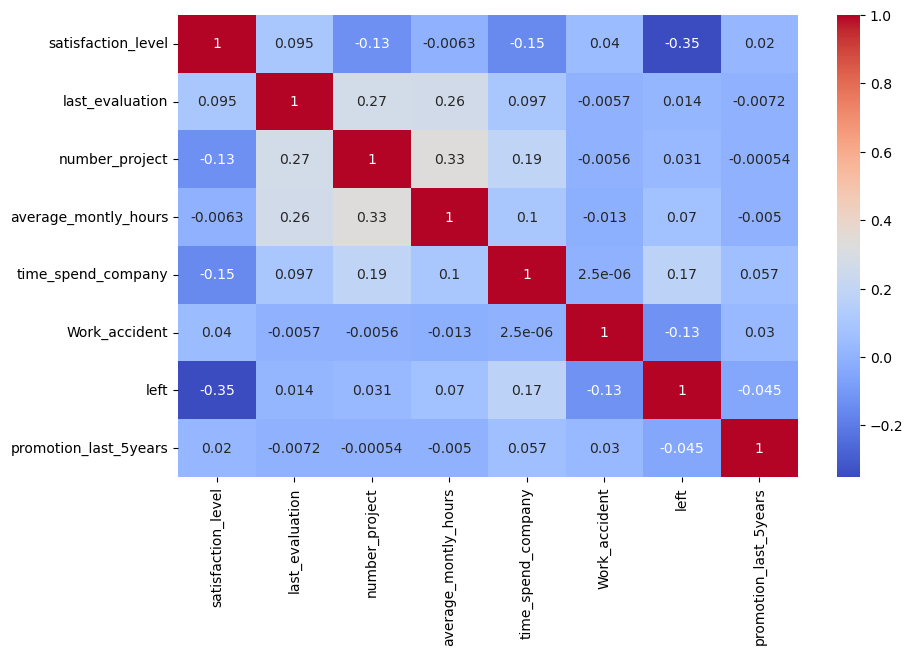

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use only numeric columns
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [11]:
from sklearn.cluster import KMeans

# Filter employees who left
left_emp = df[df['left'] == 1]

X_cluster = left_emp[['satisfaction_level', 'last_evaluation']]

In [12]:


#kmeans = KMeans(n_clusters=3, random_state=42)
#left_emp['cluster'] = kmeans.fit_predict(X_cluster)


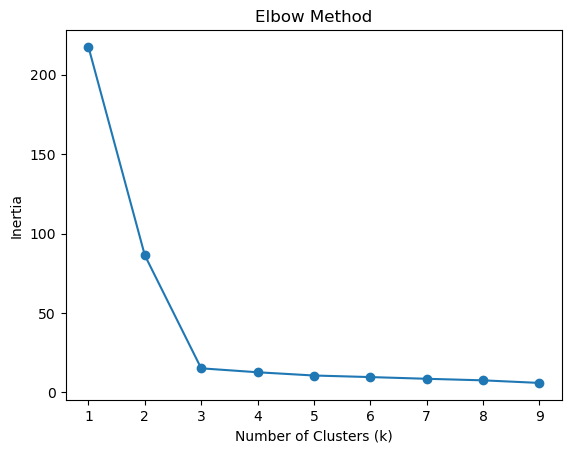

In [13]:
# finding the optimum number of clusters using elbow method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [14]:
# finding the optimium number of clusters by using silhouette score

from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.6290
k=3, Silhouette Score=0.7951
k=4, Silhouette Score=0.7387
k=5, Silhouette Score=0.6675
k=6, Silhouette Score=0.4455
k=7, Silhouette Score=0.4460
k=8, Silhouette Score=0.4490
k=9, Silhouette Score=0.3919


-> From Elbow Method we conclude that the optimum number of clusters 'K' is 3

-> From Silhoutte Score also we observe that for k=3 we get high score closer to '1' to choose for optimum number of clusters

-> So three clusters are required to seperate the data and findout the reason for leaving based on satisfaction_level and last_evaluation

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
left_emp['cluster'] = kmeans.fit_predict(X_cluster)

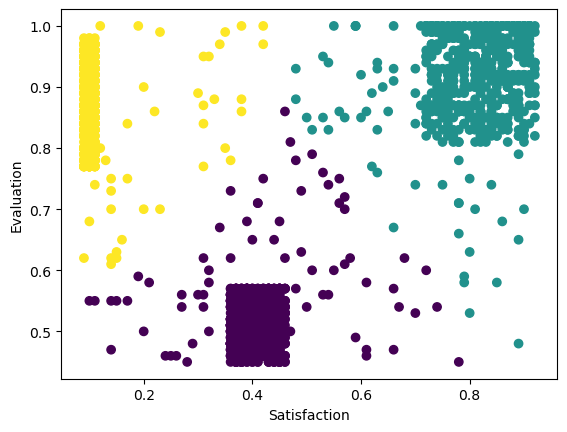

In [16]:
plt.scatter(left_emp['satisfaction_level'],
            left_emp['last_evaluation'],
            c=left_emp['cluster'],
            cmap='viridis')
plt.xlabel("Satisfaction")
plt.ylabel("Evaluation")
plt.show()

Cluster Interpretation (the conclusions drawn from the data)

Cluster 1 → Low satisfaction, low evaluation → disengaged

Cluster 2 → Low satisfaction, high evaluation → frustrated high performers 

Cluster 3 → Moderate satisfaction

In [17]:
# Converting categorical data to numerical data by using one-hot encoding
df = pd.get_dummies(df, columns=['salary', 'sales'], drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

#seperating target from features
X = df.drop('left', axis=1)
y = df['left']

# Splitting the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# As we see imbalacing in the data, applying SMOTE technique to get the data balanced
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_sm.value_counts())

left
0    7999
1    1593
Name: count, dtype: int64
left
0    7999
1    7999
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from xgboost import XGBClassifier

In [21]:
# Using Logistic Regression
lr = LogisticRegression(max_iter=1000)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(lr, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("LR F1 Score:", lr_scores.mean())

LR F1 Score: 0.8425216686188239


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Using  Naive Bayes
nb = GaussianNB()

nb_scores = cross_val_score(nb, X_train_scaled, y_train_sm, cv=cv, scoring='f1')

print("NB F1 Score:", nb_scores.mean())

NB F1 Score: 0.760508887050977


In [24]:
#Using Decision Trees
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt_scores = cross_val_score(dt, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("DT F1 Score:", dt_scores.mean())

DT F1 Score: 0.9587162711018923


In [25]:
# Using KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(knn, X_train_scaled, y_train_sm, cv=cv, scoring='f1')

print("KNN F1 Score:", knn_scores.mean())

KNN F1 Score: 0.9551733662607429


In [26]:
#SVC
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)

svm_scores = cross_val_score(svm, X_train_scaled, y_train_sm, cv=cv, scoring='f1')

print("SVM F1 Score:", svm_scores.mean())

SVM F1 Score: 0.9583910497635838


In [27]:
# Using RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf_scores = cross_val_score(rf, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("RF F1 Score:", rf_scores.mean())

RF F1 Score: 0.977622849973565


In [28]:
# Using Ensemble Boosting- AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)

ada_scores = cross_val_score(ada, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("AdaBoost F1 Score:", ada_scores.mean())

AdaBoost F1 Score: 0.9271460149997945


In [29]:
# Using Ensemble Boosting- Gradient Boost

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

gb_scores = cross_val_score(gb, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("Gradient Boosting F1 Score:", gb_scores.mean())

Gradient Boosting F1 Score: 0.971988849207932


In [30]:
# Using Ensemble Boosting- XGBoost

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_scores = cross_val_score(xgb, X_train_sm, y_train_sm, cv=cv, scoring='f1')

print("XGB F1 Score:", xgb_scores.mean())

XGB F1 Score: 0.9806758565708419


In [31]:
# Scores from all the models

print("LR F1 Score:", lr_scores.mean())
print("NB F1 Score:", nb_scores.mean())
print("DT F1 Score:", dt_scores.mean())
print("KNN F1 Score:", knn_scores.mean())
print("SVM F1 Score:", svm_scores.mean())
print("RF F1 Score:", rf_scores.mean())
print("AdaBoost F1 Score:", ada_scores.mean())
print("Gradient Boosting F1 Score:", gb_scores.mean())
print("XGB F1 Score:", xgb_scores.mean())

LR F1 Score: 0.8425216686188239
NB F1 Score: 0.760508887050977
DT F1 Score: 0.9587162711018923
KNN F1 Score: 0.9551733662607429
SVM F1 Score: 0.9583910497635838
RF F1 Score: 0.977622849973565
AdaBoost F1 Score: 0.9271460149997945
Gradient Boosting F1 Score: 0.971988849207932
XGB F1 Score: 0.9806758565708419


After evaluating the model using various algorithms using cross validation , we conclude that XGBoost Algorithm performing with high F1-Score of 0.9806758565708419


In [32]:
# Checking  complete classification report for the best model (XGBoost)
from sklearn.metrics import classification_report, confusion_matrix

xgb.fit(X_train_sm, y_train_sm)
y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2001
           1       0.94      0.93      0.93       398

    accuracy                           0.98      2399
   macro avg       0.96      0.96      0.96      2399
weighted avg       0.98      0.98      0.98      2399

[[1976   25]
 [  28  370]]



Performance Metrics used to evaluate the Models is F1-Score:

The dataset is imbalanced, with significantly more employees staying than leaving. Therefore, accuracy is not a reliable metric as it can give misleading results.

F1-score was used as the primary evaluation metric because it provides a balance between precision and recall:

Precision ensures correctness of predicted values
Recall ensures identification of employees likely to leave

Thus, F1-score is more appropriate for this problem as it accounts for both false positives and false negatives.

*Retention Strategies for Targeted Employees

Based on exploratory data analysis (EDA), clustering results, and model predictions, the following targeted retention strategies are recommended:


1) For Low Satisfaction Employees
 
    *Regular feedback sessions

    *Better work-life balance

2) For High Performers Leaving
 
    *Promotions

    *Recognition programs

    *Salary hikes

3) For Overworked Employees
   
    *Limit monthly hours

    *Redistribute workload

4) For Long-term Employees (No Promotion)
   
    *Career growth plans

    *Internal mobility